
# 02425 Diffusion and stochastich differential equations


## WEEK 3: Brownian motion

In [144]:
import numpy as np
import random
from numpy import random
from matplotlib import pyplot as plt
import scipy.stats as stats


In this exercise we will study the linear SDE, both in the time domain and in the sprectrum domain.

## Steady-state variance structure for a mass-spring-damper syste

### Exercise 1

We have a linear ito process on the form $\mathit{dX}_{t}=\mathit{AX}_{t}\mathit{dt}+\mathit{GdB}_{t}$, Where $A$ and $G$ are given as

$$A =\left[\begin{array}{cc}
0 & 1 
\\
 -\frac{k}{m} & -\frac{c}{m} 
\end{array}\right],
\qquad
G =\left[\begin{array}{c}
0 
\\
 \frac{\sigma}{m} 
\end{array}\right]$$

### Exercise 2

In [145]:
T = 1000
dt = 0.01
m = 1
k = 0.5
c = 0.2
sigma2 = 100
A = np.array([[0, 1],[-k/m, -c/m]])
G = np.array([[0],[np.sqrt(sigma2/m)]])

def eulermaruyama(T,dt,m,k,c,sigma2, A, G):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros((N,2))
    X[0] = np.array([0, 0])
    for i in range(1, N):
        dW1 = np.random.normal(0, np.sqrt(dt))
        X[i] = X[i-1] + A @ X[i-1] * dt + G.T * np.array([dW1])
    return t, X


t, X = eulermaruyama(T, dt, m, k, c, sigma2, A, G)

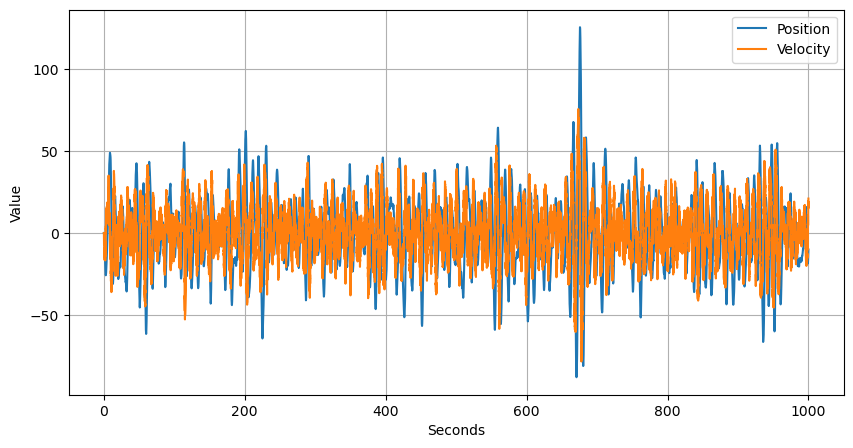

In [146]:
plt.figure(figsize=(10, 5))

plt.plot(t, X[:, 0], label="Position")
plt.plot(t, X[:, 1], label="Velocity")

plt.xlabel("Seconds")
plt.ylabel("Value")
plt.legend()
plt.grid()

plt.show()

### Exercise 3

From the previouse plot we can maybe assume that out process has got to the steady state already by $t = 20 sec$. Therefore we can take these values from $20 sec$ and above and numerically calculate the variance of $Q_t$ and $V_t$.

In [147]:
steadyPosition = X[:, 0][2000:]
steadyVelocity = X[:, 1][2000:]



print("Mean of Position:", np.mean(steadyPosition))
print("Variance of Position:", np.var(steadyPosition))
print("")
print("Mean of Velocity:", np.mean(steadyVelocity))
print("Variance of Velocity:", np.var(steadyVelocity))

Mean of Position: -0.6097480171581199
Variance of Position: 586.5785005015852

Mean of Velocity: 0.012593389306239766
Variance of Velocity: 293.2668163184561


### Exercise 4

We can calculate the expected steady state kinetic energy, and the expected steady state potenital energy analytically and compare with the numerical approximations.

$$
E_{\mathrm{kin}}^{\mathrm{ss}}
=
\frac{1}{2}mE[V_t^2]
=
\frac{1}{2}m\,\mathrm{Var}(V_t)
=
\frac{1}{2}\cdot 1 \cdot 250
=
125
$$

$$
E_{\mathrm{pot}}^{\mathrm{ss}}
=
\frac{1}{2}kE[Q_t^2]
=
\frac{1}{2}k\,\mathrm{Var}(Q_t)
=
\frac{1}{2}\cdot 0.5 \cdot 500
=
125
$$

In [148]:
print("Expected kinetic energy:", 0.5 * m * np.mean(steadyVelocity**2))
print("Expected potential energy:", 0.5 * k * np.mean(steadyPosition**2))

Expected kinetic energy: 146.63348745595516
Expected potential energy: 146.73757328650333


OBS: Notice that the numercial approximations has a huge fluctuations with respect to different simulations. Thus for calculating a better approximations one either needs to do many simulations and measure the variance with repsect to the terminal state for each realiation. or take T toward infinity, then for at suitable T the numerical approcimations should be near the analytical soltuions.

### Exercise 5

### Exercise 6

## Variance in a scalar linear system

Now we will consider a scalar linear sde on the form 
$$
\dot{X}_t = -\lambda X_t + \sigma U_t,
\qquad
X_0 = x
$$

here $U_t$ is the white noise. This process can be interpreted as an ito process on the following form.
$$\mathit{dX}_{t}=-\lambda X_{t}\mathit{dt} +{\sigma \mathit{dB}}_{t} \qquad X_0 = x$$

Here $B_t$ is the brownian motion.

### Exercise 7

We know that the mean of the process is given as the following:

$$E[X_t]= \exp(-\lambda)  E[X_0]=\exp(-\lambda)x$$

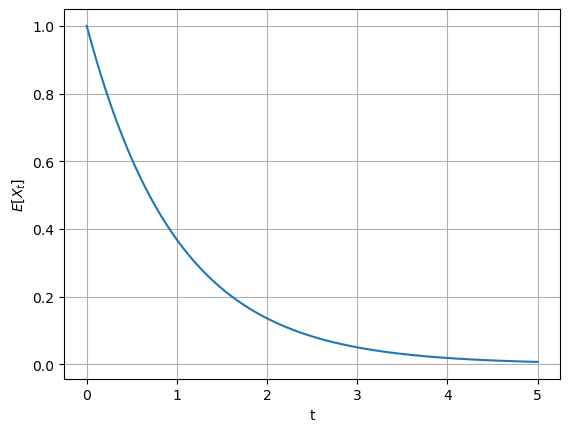

In [149]:
import numpy as np
import matplotlib.pyplot as plt

x = 1
lam = 1

t = np.linspace(0, 5, 500)

EX = x * np.exp(-lam * t)

plt.plot(t, EX)
plt.xlabel("t")
plt.ylabel(r"$E[X_t]$")
plt.grid()
plt.show()

### Exercise 8

We can solve the Lyapanov equation of the system by the following.

$$
dX_t = -\lambda X_t\,dt + \sigma\,dB_t
$$

$$
A = -\lambda, \qquad G = \sigma
$$

$$
\dot{\Sigma}(t)
= A\Sigma(t) + \Sigma(t)A^T + GG^T
= (-\lambda)\Sigma(t) + \Sigma(t)(-\lambda) + \sigma^2
= -2\lambda\Sigma(t) + \sigma^2
$$

$$
\dot{\Sigma}(t) + 2\lambda\Sigma(t) = \sigma^2
$$

Here we have a first order linear differential equation. We first solve the homogeneous equation.

$$
\dot{\Sigma}_h(t) + 2\lambda\Sigma_h(t) = 0
$$

$$
r + 2\lambda = 0
\quad \Longrightarrow \quad
r = -2\lambda
$$

$$
\Sigma_h(t) = C e^{rt}
= C e^{-2\lambda t}
$$

For the particular solution, we assume that

$$
\Sigma_p(t) = K
\quad \Longrightarrow \quad
\dot{\Sigma}_p(t) = 0
$$

Substituting this into

$$
\dot{\Sigma}(t) + 2\lambda\Sigma(t) = \sigma^2
$$

gives

$$
0 + 2\lambda K = \sigma^2
\quad \Longrightarrow \quad
K = \frac{\sigma^2}{2\lambda}
\quad \Longrightarrow \quad
\Sigma_p(t) = \frac{\sigma^2}{2\lambda}
$$

The general solution is therefore

$$
\Sigma(t)
= \Sigma_h(t) + \Sigma_p(t)
= C e^{-2\lambda t} + \frac{\sigma^2}{2\lambda}
$$

Since $X_0=x$ is deterministic,

$$
\Sigma(0)
= \operatorname{Var}(X_0)
= 0
$$

Using the initial condition,

$$
0
= C + \frac{\sigma^2}{2\lambda}
\quad \Longrightarrow \quad
C = -\frac{\sigma^2}{2\lambda}
$$

Therefore,

$$
\Sigma(t)
= -\frac{\sigma^2}{2\lambda}e^{-2\lambda t}
+ \frac{\sigma^2}{2\lambda}
$$

$$
\operatorname{Var}(X_t)
= \Sigma(t)
= \frac{\sigma^2}{2\lambda}
\left(1-e^{-2\lambda t}\right)
$$

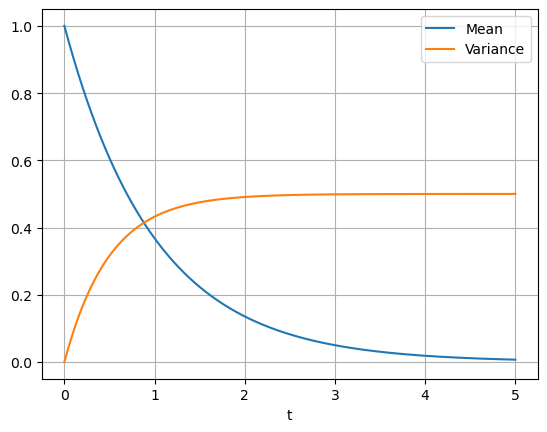

In [150]:
import numpy as np
import matplotlib.pyplot as plt

x = 1
lam = 1
sigma = 1

t = np.linspace(0, 5, 500)

mean = x * np.exp(-lam * t)

variance = sigma**2 / (2*lam) * (1 - np.exp(-2*lam*t))

plt.plot(t, mean, label="Mean")
plt.plot(t, variance, label="Variance")

plt.xlabel("t")
plt.legend()
plt.grid()
plt.show()

Its clear from the plot that variance converges to some value. This is because there exist a steady state solutiion of the lyapanocv equation (where the solution is a positive vairance, with other words a valid variance).

Now we can plot the mean $+-$ the standard deviation.

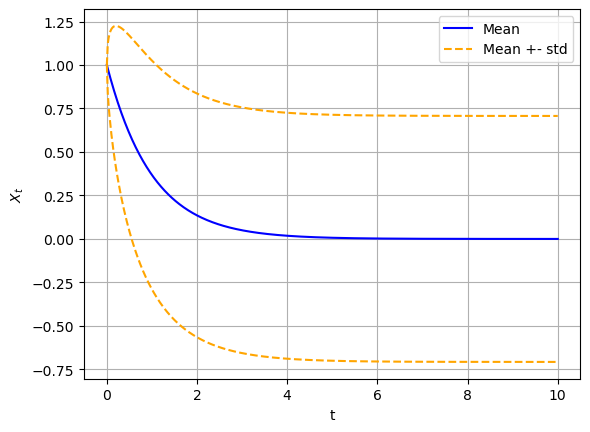

In [153]:
x = 1
lam = 1
sigma = 1

t = np.linspace(0, 10, 500)

mean = x * np.exp(-lam * t)

variance = sigma**2 / (2 * lam) * (1 - np.exp(-2 * lam * t))

std = np.sqrt(variance)

plt.plot(t, mean, label="Mean", color="blue")
plt.plot(t, mean + std, "--", label="Mean +- std", color ="orange")
plt.plot(t, mean - std, "--", color ="orange")

plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.legend()
plt.grid()

plt.show()

### Exercise 8

We can find the steadystate solution of the Lyapanov equation by the following.

$$
dX_t = -\lambda X_t\,dt + \sigma\,dB_t
$$

$$
A = -\lambda, \qquad G = \sigma
$$

The Lyapanov equation is

$$
\dot{\Sigma}(t)
= A\Sigma(t) + \Sigma(t)A^T + GG^T
= (-\lambda)\Sigma(t) + \Sigma(t)(-\lambda) + \sigma^2
= -2\lambda\Sigma(t) + \sigma^2
$$

At steady state, the variance is constant, and therefore

$$
\dot{\Sigma}(t) = 0
$$

Thus,

$$
0
= -2\lambda\Sigma_{\mathrm{ss}} + \sigma^2
$$

$$
2\lambda\Sigma_{\mathrm{ss}}
= \sigma^2
\quad \Longrightarrow \quad
\Sigma_{\mathrm{ss}}
= \frac{\sigma^2}{2\lambda}
$$

Since $\Sigma_{\mathrm{ss}}$ is the steady-state variance,

$$
\operatorname{Var}(X_t)_{\mathrm{ss}}
= \Sigma_{\mathrm{ss}}
= \frac{\sigma^2}{2\lambda}
$$


Another way to get to the exact same result is that you take the solution of the preciouse exercise at differetnitatio the function with repsect to t and then set the equation equal to 0.

Now you can compare the difference between the solution of the lyapanov equation and the solution of the steady state of the variance, for variouse values of t.

In [156]:
t = 10

print(sigma**2/2*lam - sigma**2 / (2*lam) * (1 - np.exp(-2*lam*t)))

1.0305767905727237e-09


### Exercise 9

In [ ]:
T = 10
dt = 0.01
m = 1
k = 0.5
c = 0.2
sigma2 = 100
A = np.array([[0, 1],[-k/m, -c/m]])
G = np.array([[0],[np.sqrt(sigma2/m)]])

def eulermaruyama(T,dt,lam,sigma,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x
    for i in range(1, N):
        dW1 = np.random.normal(0, np.sqrt(dt))
        X[i] = X[i-1] +  -lam* X[i-1] * dt + sigma * np.array([dW1])
    return t, X


t, X = eulermaruyama(T, dt, lam, sigma, x)

/var/folders/hx/228j6cc51r3gxlrh3q1dtnxw0000gn/T/ipykernel_12872/1136254267.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X[i] = X[i-1] +  -lam* X[i-1] * dt + sigma * np.array([dW1])


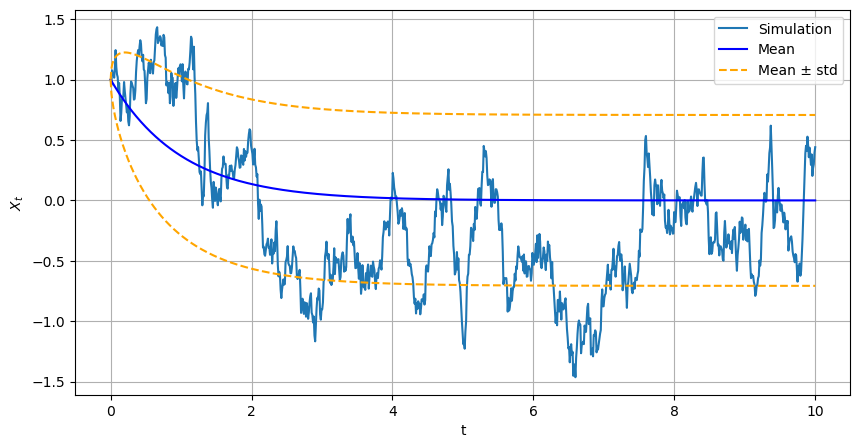

In [164]:
x = 1
lam = 1
sigma = 1

mean = x * np.exp(-lam * t)

variance = sigma**2 / (2 * lam) * (1 - np.exp(-2 * lam * t))

std = np.sqrt(variance)


plt.figure(figsize=(10, 5))

plt.plot(t, X, label="Simulation")

plt.plot(t, mean, label="Mean", color="blue")

plt.plot(t, mean + std, "--", label="Mean ± std", color="orange")

plt.plot(t, mean - std, "--", color="orange")

plt.xlabel("t")

plt.ylabel(r"$X_t$")

plt.legend()

plt.grid()

plt.show()